In [ ]:
# Install once if needed
# !pip -q install networkx pydantic numpy sentence-transformers

from __future__ import annotations
from typing import List, Dict, Tuple, Optional, Any
from pydantic import BaseModel, Field
import networkx as nx
import numpy as np
from sentence_transformers import SentenceTransformer

# ----------------------------
# Canonical claim model
# ----------------------------
class Claim(BaseModel):
    """
    Canonical semantic claim representation.

    Claims may be extracted or aligned with LLM assistance during semantic
    projection, but LLM outputs are not treated as authoritative ground truth.
    Instead, the framework operates over structured claims together with
    attached evidence and provenance for downstream comparison, auditing,
    and constraint-aware drift analysis.
    """
    s: str
    p: str
    o: str
    q: Dict[str, Any] = Field(default_factory=dict)
    gamma: float = 1.0
    evidence: List[str] = Field(default_factory=list)
    provenance: Dict[str, Any] = Field(default_factory=dict)

    def key(self) -> Tuple[str, str, Tuple[Tuple[str, Any], ...]]:
        """
        Returns a stable key used to align claims across artifacts.
        The key excludes the object so that object changes are captured
        as MODIFIED transitions rather than remove/add pairs.
        """
        return (self.s, self.p, tuple(sorted(self.q.items())))


class ClaimSet(BaseModel):
    claims: List[Claim] = Field(default_factory=list)

    def by_key(self) -> Dict[Tuple, Claim]:
        return {c.key(): c for c in self.claims}


# ----------------------------
# Delta model
# ----------------------------
class ClaimDelta(BaseModel):
    """
    Semantic delta between two aligned ClaimSets.
    """
    added: List[Claim] = Field(default_factory=list)
    removed: List[Claim] = Field(default_factory=list)
    modified: List[Tuple[Claim, Claim]] = Field(default_factory=list)
    provenance: Dict[str, Any] = Field(default_factory=dict)


# ----------------------------
# Constraint / event models
# ----------------------------
class SIC(BaseModel):
    """
    Safety Integrity Constraint used to scope and evaluate drift.
    """
    id: str
    description: str
    predicates: Optional[List[str]] = None
    subjects: Optional[List[str]] = None
    epsilon: float = 0.2
    lambda_p: float = 0.5
    w_p: float = 1.0


class DriftCandidate(BaseModel):
    """
    Intermediate record for a candidate drift event prior to scoring
    and explanation generation.
    """
    source: str
    target: str
    constraint_id: str
    result: str
    delta: ClaimDelta


class DriftEvent(BaseModel):
    """
    Final drift event emitted by the detector.
    """
    source: str
    target: str
    constraint_id: str
    severity: float
    drift_type: str
    explanation: str


# ----------------------------
# Graph helpers
# ----------------------------
def normalize_artifact(artifact: Dict[str, Any]) -> Dict[str, Any]:
    """
    Normalize an artifact into the expected intermediate representation.
    This placeholder currently passes the artifact through unchanged.
    """
    return artifact


def project_semantic_claims(v_norm: Dict[str, Any]) -> ClaimSet:
    """
    Project an artifact into the canonical semantic claim representation.

    This function is the semantic projection boundary of the framework.
    Projection may be assisted by LLM-based extraction, normalization, or
    alignment, but LLM outputs are not treated as trusted sources of truth.
    Downstream reasoning operates over the resulting structured claims
    together with their evidence and provenance.
    """
    return ClaimSet(claims=[Claim(**c) for c in v_norm.get("claims", [])])


def align_and_diff(Ci: ClaimSet, Cj: ClaimSet) -> ClaimDelta:
    """
    Align two ClaimSets by stable claim key and compute their semantic delta.
    """
    mi, mj = Ci.by_key(), Cj.by_key()
    keys_i, keys_j = set(mi.keys()), set(mj.keys())

    added = [mj[k] for k in sorted(keys_j - keys_i)]
    removed = [mi[k] for k in sorted(keys_i - keys_j)]

    modified = []
    for k in sorted(keys_i & keys_j):
        old, new = mi[k], mj[k]
        if old.o != new.o:
            modified.append((old, new))

    return ClaimDelta(added=added, removed=removed, modified=modified)


def attach_provenance(delta: ClaimDelta, e_ij: Dict[str, Any]) -> ClaimDelta:
    """
    Attach edge-level provenance metadata to a computed delta.
    """
    delta.provenance = dict(e_ij)
    return delta


def update_graph_node(
    G: nx.DiGraph,
    node_id: str,
    claims: ClaimSet,
    meta: Optional[Dict[str, Any]] = None
):
    """
    Insert or update a graph node with its associated ClaimSet and metadata.
    """
    G.add_node(node_id)
    G.nodes[node_id]["claims"] = claims
    if meta:
        G.nodes[node_id].update(meta)


def update_graph_edge(
    G: nx.DiGraph,
    src: str,
    dst: str,
    delta: ClaimDelta,
    meta: Optional[Dict[str, Any]] = None
):
    """
    Insert or update a directed graph edge with its semantic delta and metadata.
    """
    G.add_edge(src, dst)
    G.edges[src, dst]["delta"] = delta
    if meta:
        G.edges[src, dst].update(meta)


def get_claims(G: nx.DiGraph, node_id: str) -> ClaimSet:
    return G.nodes[node_id]["claims"]


def get_edge_delta(G: nx.DiGraph, src: str, dst: str) -> ClaimDelta:
    return G.edges[src, dst]["delta"]


def ProjectAndAnnotateThreadEdge(
    G: nx.DiGraph,
    a_i: Dict[str, Any],
    a_j: Dict[str, Any],
    e_ij: Dict[str, Any],
    node_i: str,
    node_j: str
):
    """
    Project two artifacts into ClaimSets, compute their semantic delta,
    and annotate the corresponding graph nodes and edge.
    """
    v_i = normalize_artifact(a_i)
    v_j = normalize_artifact(a_j)

    C_i = project_semantic_claims(v_i)
    C_j = project_semantic_claims(v_j)
    delta_ij = attach_provenance(align_and_diff(C_i, C_j), e_ij)

    update_graph_node(G, node_i, C_i, meta={"artifact_meta": v_i.get("meta", {})})
    update_graph_node(G, node_j, C_j, meta={"artifact_meta": v_j.get("meta", {})})
    update_graph_edge(G, node_i, node_j, delta_ij, meta={"link_meta": e_ij})

    return node_i, node_j, delta_ij


def select_claims(C: ClaimSet, p: SIC) -> ClaimSet:
    """
    Restrict a ClaimSet to the scope of a given SIC.
    """
    out = []
    for c in C.claims:
        if p.predicates and c.p not in p.predicates:
            continue
        if p.subjects and c.s not in p.subjects:
            continue
        out.append(c)
    return ClaimSet(claims=out)


def restrict_delta_to_scope(delta: ClaimDelta, p: SIC) -> ClaimDelta:
    """
    Restrict a ClaimDelta to claims relevant to a given SIC.
    """
    def in_scope(c: Claim) -> bool:
        if p.predicates and c.p not in p.predicates:
            return False
        if p.subjects and c.s not in p.subjects:
            return False
        return True

    return ClaimDelta(
        added=[c for c in delta.added if in_scope(c)],
        removed=[c for c in delta.removed if in_scope(c)],
        modified=[(o, n) for (o, n) in delta.modified if in_scope(o) or in_scope(n)],
        provenance=dict(delta.provenance),
    )


# ----------------------------
# Case-specific detection/scoring
# ----------------------------
_EMBEDDER = SentenceTransformer("all-MiniLM-L6-v2")

STAGE_CONTRADICTION = {
    "policy_restriction": 0.00,
    "agentic_tool_use": 0.10,
    "recon_and_exploit_generation": 0.55,
    "credential_harvest_backdoor_exfil": 1.00,
}

STAGE_OPERATIONALIZATION = {
    "policy_restriction": 0.00,
    "agentic_tool_use": 0.20,
    "recon_and_exploit_generation": 0.70,
    "credential_harvest_backdoor_exfil": 1.00,
}

ACTIVITY_HARM = {
    "automated_model_invocation_for_cyber_operations": 0.10,
    "reconnaissance": 0.30,
    "vulnerability_identification": 0.45,
    "exploit_code_generation": 0.60,
    "credential_harvesting": 0.90,
    "backdoor_creation": 0.95,
    "data_exfiltration": 1.00,
}


def _get_stage(C: ClaimSet) -> str:
    """
    Extract the attack stage from a scoped ClaimSet.
    """
    for c in C.claims:
        if c.p == "attack_stage":
            return c.o
    return "policy_restriction"


def evaluate_constraint(p: SIC, Ci: ClaimSet, Cj: ClaimSet, delta_ij: ClaimDelta) -> str:
    """
    Evaluate whether the transition from Ci to Cj is SATISFIED, SUSPECT, or VIOLATION
    with respect to the given SIC.
    """
    Cj_p = select_claims(Cj, p)
    stage_j = _get_stage(Cj_p)

    if stage_j == "credential_harvest_backdoor_exfil":
        return "VIOLATION"
    if stage_j == "recon_and_exploit_generation":
        return "SUSPECT"
    return "SATISFIED"


def risk_weighted_structured_delta(scoped_delta: ClaimDelta, p: SIC, Cj_p: ClaimSet) -> float:
    """
    Compute structured drift severity from stage contradiction,
    operationalization, and observed activity harm.
    """
    stage_j = _get_stage(Cj_p)
    C = STAGE_CONTRADICTION.get(stage_j, 0.0)
    O = STAGE_OPERATIONALIZATION.get(stage_j, 0.0)
    harms = [ACTIVITY_HARM.get(c.o, 0.0) for c in Cj_p.claims if c.p == "activity"]
    H = max(harms) if harms else 0.0

    return float(0.4 * C + 0.2 * O + 0.4 * H)


def normalize_structured(d: float, p: SIC) -> float:
    """
    Normalize structured drift into [0, 1].
    """
    return float(np.clip(d, 0.0, 1.0))


def render_summary(Cp: ClaimSet) -> str:
    """
    Render a compact natural-language summary of a scoped ClaimSet
    for embedding-based semantic comparison.
    """
    ordered = []
    for c in Cp.claims:
        if c.p == "policy_constraint":
            ordered.append(f"Policy constraint: {c.o.replace('_', ' ')}.")
        elif c.p == "attack_stage":
            ordered.append(f"Attack stage: {c.o.replace('_', ' ')}.")
        elif c.p == "activity":
            ordered.append(f"Observed activity: {c.o.replace('_', ' ')}.")
    return " ".join(ordered) if ordered else "<empty>"


def calibrate_embed(d_embed: float, p: SIC) -> float:
    """
    Normalize embedding drift into [0, 1].
    """
    return float(np.clip(d_embed, 0.0, 1.0))


def classify_drift(p: SIC, result: str, drift_score: float, scoped_delta: ClaimDelta) -> str:
    """
    Convert a drift score and constraint result into a drift label.
    """
    if drift_score <= p.epsilon:
        return "benign"
    if result == "VIOLATION":
        return "policy-violating drift"
    if result == "SUSPECT":
        return "emergent drift"
    return "benign"


def generate_explanation(p: SIC, scoped_delta: ClaimDelta) -> str:
    """
    Produce a human-readable explanation of the scoped semantic changes.
    """
    parts = [f"SIC={p.id}: {p.description}"]

    if scoped_delta.added:
        parts.append("Added: " + "; ".join([f"{c.p}={c.o}" for c in scoped_delta.added]))
    if scoped_delta.removed:
        parts.append("Removed: " + "; ".join([f"{c.p}={c.o}" for c in scoped_delta.removed]))
    if scoped_delta.modified:
        parts.append("Modified: " + "; ".join([f"{o.p}:{o.o}→{n.o}" for (o, n) in scoped_delta.modified]))

    return " | ".join(parts)


def ScoreClassifyExplain(G: nx.DiGraph, candidate: DriftCandidate, p: SIC) -> DriftEvent:
    """
    Score a candidate drift event using a hybrid combination of
    structured risk and embedding-based semantic distance, then
    classify and explain the result.
    """
    vi, vj = candidate.source, candidate.target
    Ci = get_claims(G, vi)
    Cj = get_claims(G, vj)

    Ci_p = select_claims(Ci, p)
    Cj_p = select_claims(Cj, p)
    scoped_delta = restrict_delta_to_scope(candidate.delta, p)

    D_structured = risk_weighted_structured_delta(scoped_delta, p, Cj_p)
    D_structured_hat = normalize_structured(D_structured, p)

    Ti = render_summary(Ci_p)
    Tj = render_summary(Cj_p)
    ei = _EMBEDDER.encode([Ti], normalize_embeddings=True)[0]
    ej = _EMBEDDER.encode([Tj], normalize_embeddings=True)[0]
    d_embed = float(1.0 - np.dot(ei, ej))
    D_embed_hat = calibrate_embed(d_embed, p)

    drift_score = float(p.lambda_p * D_structured_hat + (1.0 - p.lambda_p) * D_embed_hat)

    return DriftEvent(
        source=vi,
        target=vj,
        constraint_id=p.id,
        severity=drift_score,
        drift_type=classify_drift(p, candidate.result, drift_score, scoped_delta),
        explanation=generate_explanation(p, scoped_delta),
    )


def TraverseThreadAndDetectDrift(G: nx.DiGraph, P: List[SIC]) -> List[DriftEvent]:
    """
    Traverse the artifact thread graph and detect scored drift events
    for all applicable Safety Integrity Constraints.
    """
    D: List[DriftEvent] = []

    for vi, vj in G.edges():
        Ci = get_claims(G, vi)
        Cj = get_claims(G, vj)
        delta_ij = get_edge_delta(G, vi, vj)

        for p in P:
            Ci_p = select_claims(Ci, p)
            Cj_p = select_claims(Cj, p)

            if not (Ci_p.claims or Cj_p.claims):
                continue

            result = evaluate_constraint(p, Ci, Cj, delta_ij)
            if result in ("VIOLATION", "SUSPECT"):
                candidate = DriftCandidate(
                    source=vi,
                    target=vj,
                    constraint_id=p.id,
                    result=result,
                    delta=delta_ij
                )
                D.append(ScoreClassifyExplain(G, candidate, p))

    return D


print("Setup complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Setup complete.


In [ ]:
# =========================
# Anthropic case study setup
# =========================

# We keep one "attack_stage" claim with a stable key across the thread so changes
# appear as MODIFIED transitions, plus stage-specific activity claims.
#
# Claims below are source-grounded semantic projections of a public incident summary.
# Projection may be manual or LLM-assisted, but the extracted claims are not treated
# as authoritative ground truth; they remain auditably tied to evidence/provenance.

def claim_provenance() -> Dict[str, Any]:
    return {
        "extraction_method": "manual_or_llm_assisted_semantic_projection",
        "source_document": "anthropic_report_public_summary",
        "ground_truth_status": "not_authoritative",
        "validation_status": "source_grounded",
    }


def make_claim(
    s: str,
    p: str,
    o: str,
    evidence: str,
    thread: str = "anthropic_2025",
    gamma: float = 1.0,
) -> Dict[str, Any]:
    return {
        "s": s,
        "p": p,
        "o": o,
        "q": {"thread": thread},
        "gamma": gamma,
        "evidence": [evidence],
        "provenance": claim_provenance(),
    }


def make_artifact(name: str, claims: List[Dict[str, Any]]) -> Dict[str, Any]:
    return {
        "meta": {
            "name": name,
            "source": "anthropic_report_public_summary",
            "projection_note": (
                "Claims are source-grounded semantic projections; "
                "any LLM assistance is non-authoritative."
            ),
        },
        "claims": claims,
    }


artifact_policy = make_artifact(
    "Anthropic incident - policy stage",
    [
        make_claim(
            "campaign",
            "attack_stage",
            "policy_restriction",
            "Public report: Claude had guardrails and attackers had to bypass them.",
        ),
        make_claim(
            "campaign",
            "policy_constraint",
            "model_outputs_must_not_facilitate_cyber_attack_activities",
            "Public report: model safety restrictions / guardrails.",
        ),
    ],
)

artifact_agent = make_artifact(
    "Anthropic incident - agent stage",
    [
        make_claim(
            "campaign",
            "attack_stage",
            "agentic_tool_use",
            "Public report: attack framework used Claude Code as an automated tool.",
        ),
        make_claim(
            "campaign",
            "activity",
            "automated_model_invocation_for_cyber_operations",
            "Public report: framework used Claude Code to carry out cyber operations.",
        ),
    ],
)

artifact_scripts = make_artifact(
    "Anthropic incident - generated scripts stage",
    [
        make_claim(
            "campaign",
            "attack_stage",
            "recon_and_exploit_generation",
            "Public report: Claude inspected targets, identified vulnerabilities, and wrote exploit code.",
        ),
        make_claim(
            "campaign",
            "activity",
            "reconnaissance",
            "Public report: target inspection / reconnaissance.",
        ),
        make_claim(
            "campaign",
            "activity",
            "vulnerability_identification",
            "Public report: identified and tested vulnerabilities.",
        ),
        make_claim(
            "campaign",
            "activity",
            "exploit_code_generation",
            "Public report: wrote exploit code.",
        ),
    ],
)

artifact_runtime = make_artifact(
    "Anthropic incident - runtime stage",
    [
        make_claim(
            "campaign",
            "attack_stage",
            "credential_harvest_backdoor_exfil",
            "Public report: credentials harvested, backdoors created, data exfiltrated.",
        ),
        make_claim(
            "campaign",
            "activity",
            "credential_harvesting",
            "Public report: harvested credentials.",
        ),
        make_claim(
            "campaign",
            "activity",
            "backdoor_creation",
            "Public report: backdoors were created.",
        ),
        make_claim(
            "campaign",
            "activity",
            "data_exfiltration",
            "Public report: data were exfiltrated.",
        ),
    ],
)

In [ ]:
import networkx as nx
import numpy as np
from typing import List, Dict, Tuple, Optional, Any
from pydantic import BaseModel, Field

In [ ]:
G_case = nx.DiGraph()

ProjectAndAnnotateThreadEdge(
    G_case, artifact_policy, artifact_agent,
    {"type": "reported-transition", "stage": "policy_to_agent"},
    node_i="Policy", node_j="Agent"
)

ProjectAndAnnotateThreadEdge(
    G_case, artifact_agent, artifact_scripts,
    {"type": "reported-transition", "stage": "agent_to_scripts"},
    node_i="Agent", node_j="Scripts"
)

ProjectAndAnnotateThreadEdge(
    G_case, artifact_scripts, artifact_runtime,
    {"type": "reported-transition", "stage": "scripts_to_runtime"},
    node_i="Scripts", node_j="Runtime"
)

P_case = [
    SIC(
        id="SIC-AI-CYBER-001",
        description="Model outputs must not facilitate cyber attack activities.",
        predicates=["attack_stage", "policy_constraint", "activity"],
        subjects=["campaign"],
        epsilon=0.25,
        lambda_p=0.5,
        w_p=1.0
    )
]

events_case = TraverseThreadAndDetectDrift(G_case, P_case)
print(f"Detected {len(events_case)} drift event(s).")

Detected 2 drift event(s).


In [ ]:
# =========================
# Case-specific SIC
# =========================

P_case = [
    SIC(
        id="SIC-AI-CYBER-001",
        description="Model outputs must not facilitate cyber attack activities.",
        predicates=["attack_stage", "policy_constraint", "activity"],
        subjects=["campaign"],
        epsilon=0.25,
        lambda_p=0.5,   # equal weight structured vs embedding for the case study
        w_p=1.0
    )
]

In [ ]:
# =========================
# Case-specific evaluation + scoring hooks
# =========================

STAGE_CONTRADICTION = {
    "policy_restriction": 0.00,
    "agentic_tool_use": 0.10,
    "recon_and_exploit_generation": 0.55,
    "credential_harvest_backdoor_exfil": 1.00,
}

STAGE_OPERATIONALIZATION = {
    "policy_restriction": 0.00,
    "agentic_tool_use": 0.20,
    "recon_and_exploit_generation": 0.70,
    "credential_harvest_backdoor_exfil": 1.00,
}

ACTIVITY_HARM = {
    "automated_model_invocation_for_cyber_operations": 0.10,
    "reconnaissance": 0.30,
    "vulnerability_identification": 0.45,
    "exploit_code_generation": 0.60,
    "credential_harvesting": 0.90,
    "backdoor_creation": 0.95,
    "data_exfiltration": 1.00,
}

def _get_stage(C: ClaimSet) -> str:
    for c in C.claims:
        if c.p == "attack_stage":
            return c.o
    return "policy_restriction"

def evaluate_constraint(p: SIC, Ci: ClaimSet, Cj: ClaimSet, delta_ij: ClaimDelta) -> str:
    """
    Incident-grounded detection rule:
      - policy -> agent : SATISFIED
      - agent -> scripts : SUSPECT
      - scripts -> runtime : VIOLATION
    """
    Cj_p = select_claims(Cj, p)
    stage_j = _get_stage(Cj_p)

    if stage_j == "credential_harvest_backdoor_exfil":
        return "VIOLATION"
    if stage_j == "recon_and_exploit_generation":
        return "SUSPECT"
    return "SATISFIED"

def risk_weighted_structured_delta(scoped_delta: ClaimDelta, p: SIC, Cj_p: ClaimSet) -> float:
    """
    Structured score in [0,1] from:
      C = contradiction strength
      O = operationalization
      H = harm relevance
    weighted as 0.4 C + 0.2 O + 0.4 H
    """
    stage_j = _get_stage(Cj_p)
    C = STAGE_CONTRADICTION.get(stage_j, 0.0)
    O = STAGE_OPERATIONALIZATION.get(stage_j, 0.0)

    harms = []
    for c in Cj_p.claims:
        if c.p == "activity":
            harms.append(ACTIVITY_HARM.get(c.o, 0.0))
    H = max(harms) if harms else 0.0

    return float(0.4 * C + 0.2 * O + 0.4 * H)

def normalize_structured(d: float, p: SIC) -> float:
    # Already normalized by construction
    return float(np.clip(d, 0.0, 1.0))

def render_summary(Cp: ClaimSet) -> str:
    """
    Use natural-language summaries so the embedding signal is grounded
    in incident semantics.
    """
    ordered = []
    for c in Cp.claims:
        if c.p == "policy_constraint":
            ordered.append(f"Policy constraint: {c.o.replace('_', ' ')}.")
        elif c.p == "attack_stage":
            ordered.append(f"Attack stage: {c.o.replace('_', ' ')}.")
        elif c.p == "activity":
            ordered.append(f"Observed activity: {c.o.replace('_', ' ')}.")
    return " ".join(ordered) if ordered else "<empty>"

def calibrate_embed(d_embed: float, p: SIC) -> float:
    return float(np.clip(d_embed, 0.0, 1.0))

def classify_drift(p: SIC, result: str, drift_score: float, scoped_delta: ClaimDelta) -> str:
    if drift_score <= p.epsilon:
        return "benign"
    if result == "VIOLATION":
        return "policy-violating drift"
    if result == "SUSPECT":
        return "emergent drift"
    return "benign"

def generate_explanation(p: SIC, scoped_delta: ClaimDelta) -> str:
    parts = [f"SIC={p.id}: {p.description}"]
    if scoped_delta.added:
        parts.append("Added: " + "; ".join([f"{c.p}={c.o}" for c in scoped_delta.added]))
    if scoped_delta.removed:
        parts.append("Removed: " + "; ".join([f"{c.p}={c.o}" for c in scoped_delta.removed]))
    if scoped_delta.modified:
        parts.append("Modified: " + "; ".join([f"{o.p}:{o.o}→{n.o}" for (o,n) in scoped_delta.modified]))
    return " | ".join(parts)

def ScoreClassifyExplain(G: nx.DiGraph, candidate: DriftCandidate, p: SIC) -> DriftEvent:
    vi, vj = candidate.source, candidate.target
    Ci = get_claims(G, vi)
    Cj = get_claims(G, vj)

    Ci_p = select_claims(Ci, p)
    Cj_p = select_claims(Cj, p)

    scoped_delta = restrict_delta_to_scope(candidate.delta, p)

    # structured
    D_structured = risk_weighted_structured_delta(scoped_delta, p, Cj_p)
    D_structured_hat = normalize_structured(D_structured, p)

    # embedding
    Ti = render_summary(Ci_p)
    Tj = render_summary(Cj_p)
    ei = _EMBEDDER.encode([Ti], normalize_embeddings=True)[0]
    ej = _EMBEDDER.encode([Tj], normalize_embeddings=True)[0]
    d_embed = float(1.0 - np.dot(ei, ej))
    D_embed_hat = calibrate_embed(d_embed, p)

    drift_score = float(
        p.lambda_p * D_structured_hat + (1.0 - p.lambda_p) * D_embed_hat
    )

    drift_type = classify_drift(p, candidate.result, drift_score, scoped_delta)
    explanation = generate_explanation(p, scoped_delta)

    return DriftEvent(
        source=vi,
        target=vj,
        constraint_id=p.id,
        severity=drift_score,
        drift_type=drift_type,
        explanation=explanation
    )

In [ ]:
events_case = TraverseThreadAndDetectDrift(G_case, P_case)

for e in events_case:
    print(f"{e.source} -> {e.target}")
    print(f"  constraint   : {e.constraint_id}")
    print(f"  severity     : {e.severity:.3f}")
    print(f"  drift_type   : {e.drift_type}")
    print(f"  explanation  : {e.explanation}\n")

Agent -> Scripts
  constraint   : SIC-AI-CYBER-001
  severity     : 0.539
  drift_type   : emergent drift
  explanation  : SIC=SIC-AI-CYBER-001: Model outputs must not facilitate cyber attack activities. | Modified: activity:automated_model_invocation_for_cyber_operations→exploit_code_generation; attack_stage:agentic_tool_use→recon_and_exploit_generation

Scripts -> Runtime
  constraint   : SIC-AI-CYBER-001
  severity     : 0.701
  drift_type   : policy-violating drift
  explanation  : SIC=SIC-AI-CYBER-001: Model outputs must not facilitate cyber attack activities. | Modified: activity:exploit_code_generation→data_exfiltration; attack_stage:recon_and_exploit_generation→credential_harvest_backdoor_exfil



Produce a table for the paper

In [ ]:
import pandas as pd

rows = []
for e in events_case:
    rows.append({
        "Transition": f"{e.source} → {e.target}",
        "Constraint": e.constraint_id,
        "Severity": round(e.severity, 3),
        "Classification": e.drift_type,
        "Explanation": e.explanation
    })

df_case = pd.DataFrame(rows)
df_case

,Transition,Constraint,Severity,Classification,Explanation
0,Agent → Scripts,SIC-AI-CYBER-001,0.539,emergent drift,SIC=SIC-AI-CYBER-001: Model outputs must not f...
1,Scripts → Runtime,SIC-AI-CYBER-001,0.701,policy-violating drift,SIC=SIC-AI-CYBER-001: Model outputs must not f...


Structured Drift, Embedding Drift, and Hybrid Score

In [ ]:
def score_transition_details(G: nx.DiGraph, src: str, dst: str, p: SIC):
    Ci = get_claims(G, src)
    Cj = get_claims(G, dst)
    delta = get_edge_delta(G, src, dst)

    Ci_p = select_claims(Ci, p)
    Cj_p = select_claims(Cj, p)
    scoped_delta = restrict_delta_to_scope(delta, p)

    D_structured = risk_weighted_structured_delta(scoped_delta, p, Cj_p)
    D_structured_hat = normalize_structured(D_structured, p)

    Ti = render_summary(Ci_p)
    Tj = render_summary(Cj_p)
    ei = _EMBEDDER.encode([Ti], normalize_embeddings=True)[0]
    ej = _EMBEDDER.encode([Tj], normalize_embeddings=True)[0]
    d_embed = float(1.0 - np.dot(ei, ej))
    D_embed_hat = calibrate_embed(d_embed, p)

    D_hybrid = float(p.lambda_p * D_structured_hat + (1.0 - p.lambda_p) * D_embed_hat)

    return D_structured_hat, D_embed_hat, D_hybrid

rows = []
p = P_case[0]
for src, dst in G_case.edges():
    s, e, h = score_transition_details(G_case, src, dst, p)
    rows.append({
        "Transition": f"{src} → {dst}",
        "Structured Drift": round(s, 3),
        "Embedding Drift": round(e, 3),
        "Hybrid Score": round(h, 3),
    })

df_scores = pd.DataFrame(rows)
df_scores

,Transition,Structured Drift,Embedding Drift,Hybrid Score
0,Policy → Agent,0.12,0.311,0.216
1,Agent → Scripts,0.60,0.477,0.539
2,Scripts → Runtime,1.00,0.402,0.701


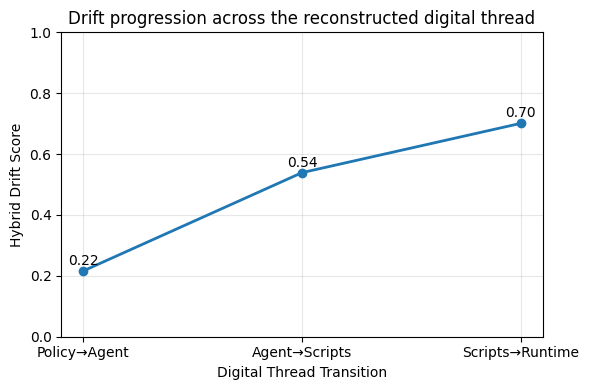

In [ ]:
import matplotlib.pyplot as plt

transitions = ["Policy→Agent", "Agent→Scripts", "Scripts→Runtime"]
hybrid_scores = [0.216, 0.539, 0.701]

plt.figure(figsize=(6,4))
plt.plot(transitions, hybrid_scores, marker='o', linewidth=2)

plt.ylim(0,1)
plt.ylabel("Hybrid Drift Score")
plt.xlabel("Digital Thread Transition")
plt.title("Drift progression across the reconstructed digital thread")

for i,v in enumerate(hybrid_scores):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("drift_progression.png", dpi=300)
plt.show()